# Pairwise Fold Distribution Shift Analysis for Lo-Hi Hi Datasets

This notebook analyzes whether the three Hi subsets of each Lo-Hi dataset are distinguishable from each other beyond the original ECFP4 Tanimoto split criterion. The Hi benchmark is designed to simulate hit identification under novelty constraints, where train and test molecules are forced to be dissimilar under ECFP4 Tanimoto similarity, and each dataset is organized into three complementary folds/subsets. This makes fold-to-fold distinguishability a natural diagnostic for distribution shift.

## Methodology: Shift Detection as Binary Classification

We treat distribution-shift detection as a binary classification problem. For each dataset, we reconstruct the three original subsets as `F1 = test_3`, `F2 = test_2`, and `F3 = test_1`, then build the three pairwise discrimination tasks: `F1_vs_F2`, `F1_vs_F3`, and `F2_vs_F3`. In each task, molecules from the first subset receive label 0 and molecules from the second subset receive label 1. The activity label is not used.

Two complementary discrimination regimes are evaluated:
* **In-sample setting (high-capacity):** Estimates maximum separability using weakly regularized discriminators. This is only a diagnostic: if a model cannot separate two folds even in-sample, the two subsets are strongly overlapping in the chosen representation.
* **Out-of-sample setting:** Estimates generalizable shift using the same model families and hyperparameter search spaces used in the main OOD-vs-random protocol comparison. This second setting is the main shift estimate.

## Models and Representations

The discriminators are **Decision Tree (DT)**, **Logistic Regression (LR)**, and **Linear SVM**. Molecular representations include **ECFP4**, **MACCS**, and **RDKit descriptors**, although the main plots use only ECFP4 and MACCS to keep model/fingerprint comparisons aligned across DT, LR, and SVM. RDKit descriptors are retained in the CSV outputs for additional analysis. Continuous RDKit descriptors are scaled inside a pipeline; binary fingerprints are not scaled.

## The Shift Score

Throughout this study, we report the **shift score**:

$$s = 2 \cdot \text{balanced accuracy} - 1 \in [0,1]$$

Here, $s=0$ means that the two folds are not distinguishable by the discriminator, while $s=1$ means perfect distinguishability. This score is a monotonic rescaling of the proxy $\mathcal{A}$-distance from the domain-adaptation literature:

$$\hat{d}_{\mathcal{A}} = 2(1 - 2\epsilon)$$

Where $\epsilon$ is the discriminator error. Since balanced accuracy is $1-\epsilon$, we have:

$$s = \frac{\hat{d}_{\mathcal{A}}}{2}$$

> **Note:** We use $s$ in figures for readability and report $\hat{d}_{\mathcal{A}}$ in the CSV outputs for direct comparison with the domain-adaptation literature.

## Feature Extraction: List A vs. List B

The notebook also extracts the features used by the fold discriminators. 
* **List B (Shift features):** The features utilized by the fold discriminators to separate distributions.
* **List A (Activity features):** The activity-model features previously saved by the main OOD-vs-random study.

The List A vs List B overlap is computed fold-aware: for example, the shift features of `F1_vs_F2` are compared with the activity features from outer fold 1, because fold 1 uses `F1` and `F2` as the internal OOD train/validation pair.

## Linking to OOD-vs-Random Protocol

Finally, the notebook links the pairwise shift score to the OOD-vs-random protocol comparison. For each pair/fold, it computes both the difference in validation optimism and the final test benefit of OOD-based model selection. The main scatter plot uses:

$$\text{test gap} = \text{test PR-AUC}_{OOD} - \text{test PR-AUC}_{random}$$

Positive values indicate that OOD-based validation selected a model that performed better on the held-out OOD test fold.

# Pairwise Fold Distribution Shift Analysis for Lo-Hi Hi Datasets

In [78]:
from __future__ import annotations

import sys
import json
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

##  Dataset Paths and Output Directories

In [79]:
DATASETS = ["drd2", "hiv", "kdr", "sol"]
TASK = "hi"

def find_project_root(start: Path | None = None) -> Path:
    """
    Walk upward until the project root is found.
    """
    if start is None:
        start = Path.cwd().resolve()

    current = start
    while current != current.parent:
        if (
            (current / "data").exists()
            and (current / "utils").exists()
            and (current / "results").exists()
        ):
            return current
        current = current.parent

    raise RuntimeError("Could not find project root containing data/, utils/, and results/.")

PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.fingerprints import compute_fingerprints

OUT_ROOT = PROJECT_ROOT / "results" / "results_classifier_shift_test" / TASK
FIG_ROOT = OUT_ROOT / "figures"

# Root feature cache directory
FEATURE_CACHE_ROOT = PROJECT_ROOT / "features" / "classifier_shift_test" / TASK

for d in (OUT_ROOT, FIG_ROOT, FEATURE_CACHE_ROOT):
    d.mkdir(parents=True, exist_ok=True)

FINGERPRINTS = ["ecfp4", "maccs", "rdkit_desc"]

TOPK_VALUES = [10, 20, 50]

N_CV_SPLITS = 5

print(f"Datasets     : {DATASETS}")
print(f"Task         : {TASK}")
print(f"Project root : {PROJECT_ROOT}")
print(f"Output root  : {OUT_ROOT}")
print(f"Figure root  : {FIG_ROOT}")
print(f"Feature cache: {FEATURE_CACHE_ROOT}")

Datasets     : ['drd2', 'hiv', 'kdr', 'sol']
Task         : hi
Project root : /home/f.capria/drug-discovery-lohi
Output root  : /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi
Figure root  : /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/figures
Feature cache: /home/f.capria/drug-discovery-lohi/features/classifier_shift_test/hi


## Sanity Check: Input Data and Previous Results

In [80]:
def get_dataset_paths(dataset: str) -> dict:
    """
    Return all input/output paths for one Hi dataset.
    """
    data_dir = PROJECT_ROOT / "data" / TASK / dataset

    binding_results_dir = (
        PROJECT_ROOT / "results" / "results_ood_vs_random_shuffle" / TASK / dataset
    )

    out_dir = OUT_ROOT / dataset
    fig_dir = out_dir / "figures"
    feat_dir = out_dir / "discriminator_features"
    feature_cache_dir = FEATURE_CACHE_ROOT / dataset

    for d in (out_dir, fig_dir, feat_dir, feature_cache_dir):
        d.mkdir(parents=True, exist_ok=True)

    return {
        "data_dir": data_dir,
        "binding_results_dir": binding_results_dir,
        "out_dir": out_dir,
        "fig_dir": fig_dir,
        "feat_dir": feat_dir,
        "feature_cache_dir": feature_cache_dir,
    }

## Reconstruct Hi Subsets and Pairwise Fold Task

In [81]:
for dataset in DATASETS:
    paths = get_dataset_paths(dataset)
    data_dir = paths["data_dir"]

    print(f"\nChecking {dataset}-{TASK}")
    print("Data dir:", data_dir)

    assert data_dir.exists(), f"Missing data directory: {data_dir}"

    for fname in ["test_1.csv", "test_2.csv", "test_3.csv"]:
        path = data_dir / fname
        assert path.exists(), f"Missing file: {path}"

    if not paths["binding_results_dir"].exists():
        print(f"Warning: binding results directory not found: {paths['binding_results_dir']}")
        print("Feature overlap with activity models will be skipped unless this directory exists.")
    else:
        print("Binding results directory found.")


Checking drd2-hi
Data dir: /home/f.capria/drug-discovery-lohi/data/hi/drd2
Binding results directory found.

Checking hiv-hi
Data dir: /home/f.capria/drug-discovery-lohi/data/hi/hiv
Binding results directory found.

Checking kdr-hi
Data dir: /home/f.capria/drug-discovery-lohi/data/hi/kdr
Binding results directory found.

Checking sol-hi
Data dir: /home/f.capria/drug-discovery-lohi/data/hi/sol
Binding results directory found.


In [82]:
SUBSET_FILES = {
    "F1": "test_3.csv",
    "F2": "test_2.csv",
    "F3": "test_1.csv",
}

PAIRS = list(combinations(["F1", "F2", "F3"], 2))


def load_subsets(dataset: str) -> dict[str, pd.DataFrame]:
    paths = get_dataset_paths(dataset)
    data_dir = paths["data_dir"]

    subsets = {}
    for subset_name, filename in SUBSET_FILES.items():
        path = data_dir / filename
        if not path.exists():
            raise FileNotFoundError(f"Missing file: {path}")

        df = pd.read_csv(path).copy()
        df["subset"] = subset_name
        df["source_file"] = filename
        subsets[subset_name] = df

    return subsets


for dataset in DATASETS:
    subsets_tmp = load_subsets(dataset)
    print(f"\n{dataset.upper()}-{TASK}")
    for subset_name, df in subsets_tmp.items():
        print(f"  {subset_name} ({SUBSET_FILES[subset_name]}): {len(df)} molecules")
    print(f"  Pairs: {PAIRS}")


DRD2-hi
  F1 (test_3.csv): 1191 molecules
  F2 (test_2.csv): 1194 molecules
  F3 (test_1.csv): 1190 molecules
  Pairs: [('F1', 'F2'), ('F1', 'F3'), ('F2', 'F3')]

HIV-hi
  F1 (test_3.csv): 7848 molecules
  F2 (test_2.csv): 7848 molecules
  F3 (test_1.csv): 7847 molecules
  Pairs: [('F1', 'F2'), ('F1', 'F3'), ('F2', 'F3')]

KDR-hi
  F1 (test_3.csv): 2285 molecules
  F2 (test_2.csv): 3125 molecules
  F3 (test_1.csv): 3116 molecules
  Pairs: [('F1', 'F2'), ('F1', 'F3'), ('F2', 'F3')]

SOL-hi
  F1 (test_3.csv): 721 molecules
  F2 (test_2.csv): 721 molecules
  F3 (test_1.csv): 721 molecules
  Pairs: [('F1', 'F2'), ('F1', 'F3'), ('F2', 'F3')]


## Featurization and pair dataset builder

In [83]:
def get_smiles_col(df: pd.DataFrame) -> str:
    """Return the SMILES column name."""
    for col in ["smiles", "SMILES", "canonical_smiles"]:
        if col in df.columns:
            return col
    raise ValueError(f"No SMILES column found. Available columns: {df.columns.tolist()}")


def get_feature_names(fp_type: str, n_features: int) -> list[str]:
    """Return feature names for each molecular representation."""
    if fp_type == "ecfp4":
        return [f"ecfp4_bit_{i}" for i in range(n_features)]

    if fp_type == "maccs":
        return [f"maccs_key_{i}" for i in range(n_features)]

    if fp_type == "rdkit_desc":
        try:
            from rdkit.Chem import Descriptors
            names = [name for name, _ in Descriptors._descList]
            return names[:n_features]
        except Exception:
            return [f"rdkit_desc_{i}" for i in range(n_features)]

    return [f"{fp_type}_feature_{i}" for i in range(n_features)]


def build_pair_dataset(
    dataset: str,
    subsets: dict[str, pd.DataFrame],
    fold_a: str,
    fold_b: str,
    fp_type: str,
) -> tuple[np.ndarray, np.ndarray, list[str], pd.DataFrame]:
    """
    Build one binary fold-discrimination dataset.

    Label convention:
        fold_a -> 0
        fold_b -> 1

    The activity label is not used here.
    """
    df_a = subsets[fold_a].copy()
    df_b = subsets[fold_b].copy()

    smiles_col = get_smiles_col(df_a)
    pair_name = f"{fold_a}_vs_{fold_b}"

    df_a["shift_label"] = 0
    df_b["shift_label"] = 1

    pair_df = pd.concat([df_a, df_b], ignore_index=True)
    pair_df["dataset"] = dataset
    pair_df["pair"] = pair_name
    pair_df["fold_a"] = fold_a
    pair_df["fold_b"] = fold_b

    smiles = pair_df[smiles_col].astype(str).tolist()
    y = pair_df["shift_label"].to_numpy(dtype=int)

    cache_path = (
        get_dataset_paths(dataset)["feature_cache_dir"]
        / f"{pair_name}_{fp_type}.npz"
    )

    X = compute_fingerprints(
        smiles_list=smiles,
        fp_type=fp_type,
        cache_path=cache_path,
    )

    feature_names = get_feature_names(fp_type, X.shape[1])

    return X, y, feature_names, pair_df

## Utility: Suppress RDKit and Featurization Logs

In [84]:
import os
import contextlib
from rdkit import RDLogger

VERBOSE = False

@contextlib.contextmanager
def silence_output():
    """
    Suppress noisy stdout/stderr and RDKit logs during featurization and fitting.
    """
    RDLogger.DisableLog("rdApp.*")
    with open(os.devnull, "w") as devnull:
        with contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
            yield
    RDLogger.EnableLog("rdApp.*")

## High-Capacity In-Sample Discrimination

In [ ]:
def make_high_capacity_discriminators(fp_type: str) -> dict:
    """
    High-capacity / weakly-regularized fold discriminators.
    Used only for in-sample maximum separability.
    """
    scale = fp_type == "rdkit_desc"

    dt = DecisionTreeClassifier(
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        ccp_alpha=0.0,
        random_state=RANDOM_STATE,
    )

    lr = LogisticRegression(
        C=1e4,
        penalty="l2",
        solver="lbfgs",
        max_iter=20000,
        random_state=RANDOM_STATE,
    )

    svm = LinearSVC(
        C=1e4,
        max_iter=20000,
        random_state=RANDOM_STATE,
    )

    if scale:
        lr = Pipeline([
            ("scaler", StandardScaler()),
            ("model", lr),
        ])
        svm = Pipeline([
            ("scaler", StandardScaler()),
            ("model", svm),
        ])

    return {
        "DT": dt,
        "LR": lr,
        "SVM": svm,
    }


def shift_scores_from_balanced_accuracy(bal_acc: float) -> tuple[float, float]:
    """
    Convert balanced accuracy into:
    - shift_score_01 in [0, 1]
    - proxy_A_distance in [0, 2]
    """
    shift_score_01 = max(0.0, 2.0 * bal_acc - 1.0)
    proxy_a_distance = max(0.0, 4.0 * bal_acc - 2.0)
    return shift_score_01, proxy_a_distance


insample_rows = []
fitted_high_capacity = {}

for dataset in DATASETS:
    subsets = load_subsets(dataset)

    if VERBOSE:
        print(f"\n=== High-capacity in-sample discrimination: {dataset.upper()}-{TASK} ===")

    for fold_a, fold_b in PAIRS:
        pair_name = f"{fold_a}_vs_{fold_b}"

        for fp_type in FINGERPRINTS:
            try:
                with silence_output():
                    X, y, feature_names, pair_df = build_pair_dataset(
                        dataset=dataset,
                        subsets=subsets,
                        fold_a=fold_a,
                        fold_b=fold_b,
                        fp_type=fp_type,
                    )
            except Exception as e:
                print(f"Skip {dataset} | {pair_name} | {fp_type}: {e}")
                continue

            for model_name, model in make_high_capacity_discriminators(fp_type).items():
                if VERBOSE:
                    print(f"{dataset} | {pair_name} | {fp_type} | {model_name}")

                fitted = clone(model)

                with silence_output():
                    fitted.fit(X, y)

                y_pred = fitted.predict(X)

                acc = accuracy_score(y, y_pred)
                bal_acc = balanced_accuracy_score(y, y_pred)
                shift_score_01, proxy_a_distance = shift_scores_from_balanced_accuracy(bal_acc)

                insample_rows.append({
                    "dataset": dataset,
                    "task": TASK,
                    "pair": pair_name,
                    "fold_a": fold_a,
                    "fold_b": fold_b,
                    "fingerprint": fp_type,
                    "model": model_name,
                    "evaluation": "high_capacity_insample",
                    "accuracy": acc,
                    "balanced_accuracy": bal_acc,
                    "shift_score_01": shift_score_01,
                    "proxy_A_distance": proxy_a_distance,
                    "n_samples": len(y),
                    "n_class_0": int((y == 0).sum()),
                    "n_class_1": int((y == 1).sum()),
                })

                fitted_high_capacity[(dataset, pair_name, fp_type, model_name)] = {
                    "model": fitted,
                    "feature_names": feature_names,
                    "X": X,
                    "y": y,
                    "pair_df": pair_df,
                }

df_insample = pd.DataFrame(insample_rows)

for dataset, sub in df_insample.groupby("dataset"):
    out_path = (
        get_dataset_paths(dataset)["out_dir"]
        / "discrimination_high_capacity_insample.csv"
    )
    sub.to_csv(out_path, index=False)

df_insample.to_csv(
    OUT_ROOT / "cross_dataset_discrimination_high_capacity_insample.csv",
    index=False,
)

display(
    df_insample
    .pivot_table(
        index=["dataset", "pair", "fingerprint"],
        columns="model",
        values="balanced_accuracy",
    )
    .round(3)
)

model                            DT     LR    SVM
dataset pair     fingerprint                     
drd2    F1_vs_F2 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.958  0.952
                 rdkit_desc   1.000  0.985  0.984
        F1_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.932  0.927
                 rdkit_desc   1.000  0.963  0.962
        F2_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.974  0.972
                 rdkit_desc   1.000  0.984  0.984
hiv     F1_vs_F2 ecfp4        1.000  0.789  0.790
                 maccs        1.000  0.690  0.692
                 rdkit_desc   1.000  0.699  0.698
        F1_vs_F3 ecfp4        1.000  0.775  0.776
                 maccs        1.000  0.688  0.689
                 rdkit_desc   1.000  0.706  0.707
        F2_vs_F3 ecfp4        1.000  0.825  0.825
                 maccs        0.999  0.734  0.735
                 rdkit_desc   1.000  0.747  0.748
kdr     F1_vs_F2 ecfp4        0.816  0.784  0.783
                 maccs        0.816  0.727  0.726
                 rdkit_desc   0.816  0.730  0.734
        F1_vs_F3 ecfp4        0.817  0.784  0.784
                 maccs        0.817  0.713  0.716
                 rdkit_desc   0.817  0.734  0.734
        F2_vs_F3 ecfp4        0.683  0.683  0.683
                 maccs        0.683  0.637  0.638
                 rdkit_desc   0.683  0.648  0.651
sol     F1_vs_F2 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.651  0.655
                 rdkit_desc   1.000  0.679  0.687
        F1_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        0.999  0.714  0.716
                 rdkit_desc   1.000  0.729  0.734
        F2_vs_F3 ecfp4        1.000  1.000  1.000
                 maccs        1.000  0.693  0.692
                 rdkit_desc   1.000  0.707  0.704

## Same-Search Out-of-Sample Discrimination

In [9]:
from sklearn.model_selection import GridSearchCV


def allowed_fingerprints_for_model(model_name: str) -> list[str]:
    """
    Match the fingerprint availability of the main OOD-vs-random study.
    """
    if model_name == "LR":
        return ["ecfp4", "maccs", "rdkit_desc"]
    if model_name in ["DT", "SVM"]:
        return ["ecfp4", "maccs"]
    raise ValueError(f"Unknown model_name: {model_name}")


def get_main_search_grid(dataset: str, model_name: str) -> dict:
    """
    Return the same hyperparameter grid used in the main OOD-vs-random study.

    HIV uses reduced grids for computational reasons, consistently with
    the main experiments.
    """
    is_hiv = dataset == "hiv"

    if model_name == "DT":
        if is_hiv:
            return {
                "max_depth": [3, 5, 8, 10, 15],
                "min_samples_split": [10, 20, 50],
                "min_samples_leaf": [5, 10, 20, 50],
                "criterion": ["gini", "entropy"],
                "class_weight": [None, "balanced"],
                "max_features": ["sqrt", "log2"],
                "ccp_alpha": [0.0, 0.0001, 0.001],
            }

        return {
            "max_depth": [3, 5, 7, 10, 15, 20],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 5, 10],
            "criterion": ["gini", "entropy"],
            "class_weight": [None, "balanced"],
            "max_features": ["sqrt", "log2", None],
            "ccp_alpha": [0.0, 0.0001, 0.001, 0.01],
        }

    if model_name == "LR":
        if is_hiv:
            return {
                "C": [0.01, 0.1, 1.0, 5.0, 10.0],
                "l1_ratio": [0.0, 0.5, 1.0],
                "class_weight": [None, "balanced"],
            }

        return {
            "C": [0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
            "l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],
            "class_weight": [None, "balanced"],
        }

    if model_name == "SVM":
        if is_hiv:
            return {
                "C": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
                "class_weight": [None, "balanced"],
            }

        return {
            "C": [
                0.001, 0.005, 0.01, 0.05, 0.1,
                0.25, 0.5, 1.0, 2.0, 5.0,
                10.0, 25.0, 50.0, 100.0,
            ],
            "class_weight": [None, "balanced"],
        }

    raise ValueError(f"Unknown model_name: {model_name}")


def make_main_search_discriminator(dataset: str, fp_type: str, model_name: str):
    """
    Build discriminator + grid using the same search space as the main
    protocol-comparison study.
    """
    if fp_type not in allowed_fingerprints_for_model(model_name):
        return None, None

    if model_name == "DT":
        estimator = DecisionTreeClassifier(random_state=RANDOM_STATE)
        grid = get_main_search_grid(dataset, model_name)

    elif model_name == "LR":
        max_iter = 50000 if dataset == "hiv" else 15000

        base = LogisticRegression(
            solver="saga",
            penalty="elasticnet",
            max_iter=max_iter,
            random_state=RANDOM_STATE,
        )

        grid = get_main_search_grid(dataset, model_name)

        if fp_type == "rdkit_desc":
            estimator = Pipeline([
                ("scaler", StandardScaler()),
                ("model", base),
            ])
            grid = {f"model__{k}": v for k, v in grid.items()}
        else:
            estimator = base

    elif model_name == "SVM":
        estimator = LinearSVC(
            max_iter=20000,
            random_state=RANDOM_STATE,
        )
        grid = get_main_search_grid(dataset, model_name)

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return estimator, grid


search_cv_rows = []
best_search_models = {}

skf = StratifiedKFold(
    n_splits=N_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

for dataset in DATASETS:
    subsets = load_subsets(dataset)

    if VERBOSE:
        print(f"\n=== Same-search out-of-sample discrimination: {dataset.upper()}-{TASK} ===")

    for fold_a, fold_b in PAIRS:
        pair_name = f"{fold_a}_vs_{fold_b}"

        for fp_type in FINGERPRINTS:
            try:
                with silence_output():
                    X, y, feature_names, pair_df = build_pair_dataset(
                        dataset=dataset,
                        subsets=subsets,
                        fold_a=fold_a,
                        fold_b=fold_b,
                        fp_type=fp_type,
                    )
            except Exception as e:
                print(f"Skip {dataset} | {pair_name} | {fp_type}: {e}")
                continue

            for model_name in ["DT", "LR", "SVM"]:
                estimator, param_grid = make_main_search_discriminator(
                    dataset=dataset,
                    fp_type=fp_type,
                    model_name=model_name,
                )

                if estimator is None:
                    continue

                if VERBOSE:
                    print(f"{dataset} | {pair_name} | {fp_type} | {model_name}")

                search = GridSearchCV(
                    estimator=estimator,
                    param_grid=param_grid,
                    scoring={
                        "accuracy": "accuracy",
                        "balanced_accuracy": "balanced_accuracy",
                        "roc_auc": "roc_auc",
                    },
                    refit="balanced_accuracy",
                    cv=skf,
                    n_jobs=-1,
                    return_train_score=True,
                    error_score=np.nan,
                )

                with silence_output():
                    search.fit(X, y)

                best_idx = search.best_index_
                cvres = search.cv_results_

                acc_mean = float(cvres["mean_test_accuracy"][best_idx])
                acc_std = float(cvres["std_test_accuracy"][best_idx])

                bal_mean = float(cvres["mean_test_balanced_accuracy"][best_idx])
                bal_std = float(cvres["std_test_balanced_accuracy"][best_idx])

                roc_mean = float(cvres["mean_test_roc_auc"][best_idx])
                roc_std = float(cvres["std_test_roc_auc"][best_idx])

                train_bal_mean = float(cvres["mean_train_balanced_accuracy"][best_idx])
                train_bal_std = float(cvres["std_train_balanced_accuracy"][best_idx])

                shift_score_01, proxy_a_distance = shift_scores_from_balanced_accuracy(
                    bal_mean
                )

                search_cv_rows.append({
                    "dataset": dataset,
                    "task": TASK,
                    "pair": pair_name,
                    "fold_a": fold_a,
                    "fold_b": fold_b,
                    "fingerprint": fp_type,
                    "model": model_name,
                    "evaluation": "same_search_cv",
                    "cv_accuracy_mean": acc_mean,
                    "cv_accuracy_std": acc_std,
                    "cv_balanced_accuracy_mean": bal_mean,
                    "cv_balanced_accuracy_std": bal_std,
                    "cv_roc_auc_mean": roc_mean,
                    "cv_roc_auc_std": roc_std,
                    "cv_train_balanced_accuracy_mean": train_bal_mean,
                    "cv_train_balanced_accuracy_std": train_bal_std,
                    "cv_train_test_gap_balanced_accuracy": train_bal_mean - bal_mean,
                    "shift_score_01": shift_score_01,
                    "proxy_A_distance": proxy_a_distance,
                    "best_params": json.dumps(search.best_params_),
                    "n_samples": len(y),
                    "n_class_0": int((y == 0).sum()),
                    "n_class_1": int((y == 1).sum()),
                })

                best_search_models[(dataset, pair_name, fp_type, model_name)] = {
                    "model": search.best_estimator_,
                    "feature_names": feature_names,
                    "X": X,
                    "y": y,
                    "pair_df": pair_df,
                    "best_params": search.best_params_,
                }

df_search_cv = pd.DataFrame(search_cv_rows)

for dataset, sub in df_search_cv.groupby("dataset"):
    out_path = (
        get_dataset_paths(dataset)["out_dir"]
        / "discrimination_same_search_cv.csv"
    )
    sub.to_csv(out_path, index=False)

df_search_cv.to_csv(
    OUT_ROOT / "cross_dataset_discrimination_same_search_cv.csv",
    index=False,
)

display(
    df_search_cv
    .pivot_table(
        index=["dataset", "pair", "fingerprint"],
        columns="model",
        values="proxy_A_distance",
    )
    .round(3)
)

model                            DT     LR    SVM
dataset pair     fingerprint                     
drd2    F1_vs_F2 ecfp4        1.836  1.951  1.951
                 maccs        1.770  1.705  1.715
                 rdkit_desc     NaN  1.799    NaN
        F1_vs_F3 ecfp4        1.763  1.864  1.866
                 maccs        1.736  1.622  1.612
                 rdkit_desc     NaN  1.691    NaN
        F2_vs_F3 ecfp4        1.814  1.928  1.933
                 maccs        1.832  1.784  1.794
                 rdkit_desc     NaN  1.802    NaN
hiv     F1_vs_F2 ecfp4        0.705  0.980  0.986
                 maccs        0.866  0.728  0.735
                 rdkit_desc     NaN  0.763    NaN
        F1_vs_F3 ecfp4        0.712  0.922  0.934
                 maccs        0.774  0.723  0.723
                 rdkit_desc     NaN  0.782    NaN
        F2_vs_F3 ecfp4        0.789  1.133  1.140
                 maccs        0.946  0.898  0.900
                 rdkit_desc     NaN  0.962    NaN
kdr     F1_vs_F2 ecfp4        0.946  0.968  0.979
                 maccs        1.016  0.864  0.877
                 rdkit_desc     NaN  0.867    NaN
        F1_vs_F3 ecfp4        1.002  0.997  1.007
                 maccs        0.966  0.817  0.831
                 rdkit_desc     NaN  0.891    NaN
        F2_vs_F3 ecfp4        0.512  0.494  0.458
                 maccs        0.493  0.472  0.461
                 rdkit_desc     NaN  0.498    NaN
sol     F1_vs_F2 ecfp4        0.340  0.497  0.497
                 maccs        0.380  0.239  0.241
                 rdkit_desc     NaN  0.358    NaN
        F1_vs_F3 ecfp4        0.549  0.763  0.752
                 maccs        0.499  0.588  0.580
                 rdkit_desc     NaN  0.602    NaN
        F2_vs_F3 ecfp4        0.629  0.757  0.763
                 maccs        0.555  0.494  0.480
                 rdkit_desc     NaN  0.505    NaN

## Extract List B: Fold-Discriminator Feature Importances

In [ ]:
def get_base_model(model):
    """Return final estimator if model is a Pipeline."""
    return model.steps[-1][1] if isinstance(model, Pipeline) else model


def tree_minimum_depths(tree_model, n_features: int) -> np.ndarray:
    """
    Minimum depth at which each feature appears in a fitted Decision Tree.
    Features never used receive NaN.
    """
    tree = tree_model.tree_
    min_depth = np.full(n_features, np.nan)

    stack = [(0, 0)]  # node_id, depth

    while stack:
        node_id, depth = stack.pop()
        feature_id = tree.feature[node_id]

        if feature_id >= 0:
            if np.isnan(min_depth[feature_id]) or depth < min_depth[feature_id]:
                min_depth[feature_id] = depth

            left = tree.children_left[node_id]
            right = tree.children_right[node_id]

            if left != -1:
                stack.append((left, depth + 1))
            if right != -1:
                stack.append((right, depth + 1))

    return min_depth


def extract_discriminator_importance(
    fitted_model,
    feature_names: list[str],
    model_name: str,
) -> pd.DataFrame:
    """
    Extract feature importances from a fitted fold discriminator.

    DT:
        - impurity-based feature importance
        - minimum depth

    LR/SVM:
        - coefficient
        - absolute coefficient as importance
    """
    base = get_base_model(fitted_model)
    n_features = len(feature_names)

    if model_name == "DT":
        importance = np.asarray(base.feature_importances_)
        min_depth = tree_minimum_depths(base, n_features)

        df = pd.DataFrame({
            "feature_idx": np.arange(n_features),
            "feature_name": feature_names,
            "importance": importance,
            "abs_importance": importance,
            "coefficient": np.nan,
            "direction": "tree",
            "minimum_depth": min_depth,
            "used": importance > 0,
        })

    else:
        coef = np.asarray(base.coef_).ravel()
        importance = np.abs(coef)

        df = pd.DataFrame({
            "feature_idx": np.arange(len(coef)),
            "feature_name": feature_names[:len(coef)],
            "importance": importance,
            "abs_importance": importance,
            "coefficient": coef,
            "direction": np.where(coef > 0, "towards_fold_b",
                          np.where(coef < 0, "towards_fold_a", "zero")),
            "minimum_depth": np.nan,
            "used": importance > 0,
        })

    total = df["abs_importance"].sum()
    df["normalized_importance"] = (
        df["abs_importance"] / total if total > 0 else 0.0
    )

    df = df.sort_values(
        ["abs_importance", "minimum_depth"],
        ascending=[False, True],
        na_position="last",
    ).reset_index(drop=True)

    df["rank"] = np.arange(1, len(df) + 1)

    return df


def collect_listB_from_models(model_dict: dict, source_name: str) -> pd.DataFrame:
    """
    Extract List B shift features from a fitted-model dictionary.

    Expected key:
        (dataset, pair_name, fp_type, model_name)

    Expected value:
        {
            "model": fitted estimator,
            "feature_names": list,
            ...
        }
    """
    all_rows = []

    for (dataset, pair_name, fp_type, model_name), obj in model_dict.items():
        fitted_model = obj["model"]
        feature_names = obj["feature_names"]

        df_imp = extract_discriminator_importance(
            fitted_model=fitted_model,
            feature_names=feature_names,
            model_name=model_name,
        )

        fold_a, fold_b = pair_name.split("_vs_")

        df_imp.insert(0, "source", source_name)
        df_imp.insert(0, "model", model_name)
        df_imp.insert(0, "fingerprint", fp_type)
        df_imp.insert(0, "fold_b", fold_b)
        df_imp.insert(0, "fold_a", fold_a)
        df_imp.insert(0, "pair", pair_name)
        df_imp.insert(0, "task", TASK)
        df_imp.insert(0, "dataset", dataset)

        all_rows.append(df_imp)

        top = df_imp.head(50)
        feat_dir = get_dataset_paths(dataset)["feat_dir"]
        top.to_csv(
            feat_dir / f"listB_{source_name}_{pair_name}_{fp_type}_{model_name}.csv",
            index=False,
        )

    return pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()


listB_parts = []

if "fitted_high_capacity" in globals() and fitted_high_capacity:
    listB_parts.append(
        collect_listB_from_models(
            model_dict=fitted_high_capacity,
            source_name="high_capacity_insample",
        )
    )

if "best_search_models" in globals() and best_search_models:
    listB_parts.append(
        collect_listB_from_models(
            model_dict=best_search_models,
            source_name="same_search_cv",
        )
    )

df_listB = pd.concat(listB_parts, ignore_index=True)

# Save dataset-specific full List B tables
for dataset, sub in df_listB.groupby("dataset"):
    sub.to_csv(
        get_dataset_paths(dataset)["out_dir"] / "listB_discriminator_feature_importance.csv",
        index=False,
    )

# Save cross-dataset full List B table
df_listB.to_csv(
    OUT_ROOT / "cross_dataset_listB_discriminator_feature_importance.csv",
    index=False,
)

display(
    df_listB
    .query("rank <= 10")
    .loc[:, [
        "dataset", "source", "pair", "fingerprint", "model",
        "rank", "feature_idx", "feature_name",
        "abs_importance", "coefficient", "direction", "minimum_depth"
    ]]
    .head(30)
)

## Load List A: Activity-Model Feature Importances

In [87]:
IMPORTANCE_COL_CANDIDATES = [
    "abs_importance",
    "normalized_abs_importance",
    "normalized_importance",
    "tree_importance",
    "normalized_tree_importance",
    "importance",
    "abs_weight",
    "abs_coefficient",
]

MODEL_NAME_MAP = {
    "dt": "DT",
    "decision_tree": "DT",
    "Decision Tree": "DT",
    "lr": "LR",
    "logistic_regression": "LR",
    "Logistic Regression": "LR",
    "svm": "SVM",
    "svm_linear": "SVM",
    "Linear SVM": "SVM",
}


def find_importance_col(df: pd.DataFrame) -> str:
    for col in IMPORTANCE_COL_CANDIDATES:
        if col in df.columns:
            return col
    raise ValueError(
        "No valid importance column found. "
        f"Available columns: {df.columns.tolist()}"
    )


def normalize_model_name(x) -> str:
    if pd.isna(x):
        return x
    return MODEL_NAME_MAP.get(str(x), str(x))


def load_listA_for_dataset(dataset: str) -> pd.DataFrame | None:
    """
    Load List A: activity/binding feature importances from the OOD-vs-random study.
    """
    paths = get_dataset_paths(dataset)
    path = paths["binding_results_dir"] / "feature_importance_all.csv"

    if not path.exists():
        print(f"Missing List A for {dataset}: {path}")
        return None

    df = pd.read_csv(path).copy()
    importance_col = find_importance_col(df)

    df["dataset"] = dataset
    df["source"] = "activity_model"
    df["list"] = "A_binding_activity"
    df["activity_importance"] = df[importance_col].astype(float).abs()

    if "model" in df.columns:
        df["model"] = df["model"].map(normalize_model_name)
    elif "model_short" in df.columns:
        df["model"] = df["model_short"].map(normalize_model_name)
    else:
        raise ValueError(f"No model column found in {path}")

    if "fingerprint" not in df.columns:
        if "fp_type" in df.columns:
            df["fingerprint"] = df["fp_type"]
        else:
            raise ValueError(f"No fingerprint column found in {path}")

    if "feature_idx" not in df.columns:
        raise ValueError(f"No feature_idx column found in {path}")

    if "feature_name" not in df.columns:
        df["feature_name"] = df["fingerprint"].astype(str) + "_feature_" + df["feature_idx"].astype(str)

    keep_cols = [
        "dataset", "source", "list",
        "model", "fingerprint",
        "feature_idx", "feature_name",
        "activity_importance",
    ]

    optional_cols = [
        "protocol", "fold", "rank", "direction",
        "raw_weight", "coefficient", "minimum_depth",
        "normalized_abs_importance", "tree_importance",
    ]

    keep_cols += [c for c in optional_cols if c in df.columns]

    df = df[keep_cols].copy()

    sort_cols = ["dataset", "model", "fingerprint"]
    if "protocol" in df.columns:
        sort_cols.append("protocol")
    if "fold" in df.columns:
        sort_cols.append("fold")

    df = (
        df.sort_values(sort_cols + ["activity_importance"], ascending=[True] * len(sort_cols) + [False])
        .reset_index(drop=True)
    )

    df["activity_rank"] = (
        df.groupby(sort_cols)["activity_importance"]
        .rank(method="first", ascending=False)
        .astype(int)
    )

    return df


listA_parts = []

for dataset in DATASETS:
    df_a = load_listA_for_dataset(dataset)
    if df_a is None:
        continue

    listA_parts.append(df_a)

    out_path = get_dataset_paths(dataset)["out_dir"] / "listA_activity_feature_importance.csv"
    df_a.to_csv(out_path, index=False)

df_listA = pd.concat(listA_parts, ignore_index=True) if listA_parts else pd.DataFrame()

df_listA.to_csv(
    OUT_ROOT / "cross_dataset_listA_activity_feature_importance.csv",
    index=False,
)

display(
    df_listA
    .query("activity_rank <= 10")
    .head(10)
)

,dataset,source,list,model,fingerprint,feature_idx,feature_name,activity_importance,protocol,fold,rank,direction,raw_weight,minimum_depth,normalized_abs_importance,tree_importance,activity_rank
0,drd2,activity_model,A_binding_activity,DT,ecfp4,767,ecfp4_bit_767,0.165114,OOD holdout,1,1,NaN,NaN,0.0,NaN,0.165114,1
1,drd2,activity_model,A_binding_activity,DT,ecfp4,592,ecfp4_bit_592,0.042588,OOD holdout,1,2,NaN,NaN,1.0,NaN,0.042588,2
2,drd2,activity_model,A_binding_activity,DT,ecfp4,830,ecfp4_bit_830,0.040849,OOD holdout,1,3,NaN,NaN,3.0,NaN,0.040849,3
3,drd2,activity_model,A_binding_activity,DT,ecfp4,268,ecfp4_bit_268,0.038104,OOD holdout,1,4,NaN,NaN,2.0,NaN,0.038104,4
4,drd2,activity_model,A_binding_activity,DT,ecfp4,875,ecfp4_bit_875,0.036058,OOD holdout,1,5,NaN,NaN,9.0,NaN,0.036058,5
5,drd2,activity_model,A_binding_activity,DT,ecfp4,673,ecfp4_bit_673,0.036044,OOD holdout,1,6,NaN,NaN,5.0,NaN,0.036044,6
6,drd2,activity_model,A_binding_activity,DT,ecfp4,13,ecfp4_bit_13,0.030793,OOD holdout,1,7,NaN,NaN,13.0,NaN,0.030793,7
7,drd2,activity_model,A_binding_activity,DT,ecfp4,74,ecfp4_bit_74,0.030544,OOD holdout,1,8,NaN,NaN,12.0,NaN,0.030544,8
8,drd2,activity_model,A_binding_activity,DT,ecfp4,313,ecfp4_bit_313,0.028760,OOD holdout,1,9,NaN,NaN,5.0,NaN,0.028760,9
9,drd2,activity_model,A_binding_activity,DT,ecfp4,136,ecfp4_bit_136,0.026863,OOD holdout,1,10,NaN,NaN,10.0,NaN,0.026863,10


## Reload Saved Results After Kernel Restart

In [ ]:

SHIFT_ROOT = PROJECT_ROOT / "results" / "results_classifier_shift_test" / TASK
OUT_ROOT = SHIFT_ROOT
FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

search_cv_path = OUT_ROOT / "cross_dataset_discrimination_same_search_cv.csv"
insample_path = OUT_ROOT / "cross_dataset_discrimination_high_capacity_insample.csv"
listB_path = OUT_ROOT / "cross_dataset_listB_discriminator_feature_importance.csv"
listA_path = OUT_ROOT / "cross_dataset_listA_activity_feature_importance.csv"

if not search_cv_path.exists():
    raise FileNotFoundError(f"Missing file: {search_cv_path}")

df_search_cv = pd.read_csv(search_cv_path)

df_insample = pd.read_csv(insample_path) if insample_path.exists() else pd.DataFrame()
df_listB = pd.read_csv(listB_path) if listB_path.exists() else pd.DataFrame()
df_listA = pd.read_csv(listA_path) if listA_path.exists() else pd.DataFrame()

print("Loaded:")
print(f"df_search_cv : {df_search_cv.shape} from {search_cv_path}")
print(f"df_insample  : {df_insample.shape} from {insample_path if insample_path.exists() else 'missing'}")
print(f"df_listB     : {df_listB.shape} from {listB_path if listB_path.exists() else 'missing'}")
print(f"df_listA     : {df_listA.shape} from {listA_path if listA_path.exists() else 'missing'}")

Loaded:
df_search_cv : (84, 23) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_discrimination_same_search_cv.csv
df_insample  : (108, 15) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_discrimination_high_capacity_insample.csv
df_listB     : (96168, 18) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_listB_discriminator_feature_importance.csv
df_listA     : (90960, 17) from /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_listA_activity_feature_importance.csv


## Global fold-shift heatmap and Per-Model Fold-Shift Heatmaps

C’è distribution shift tra i fold?

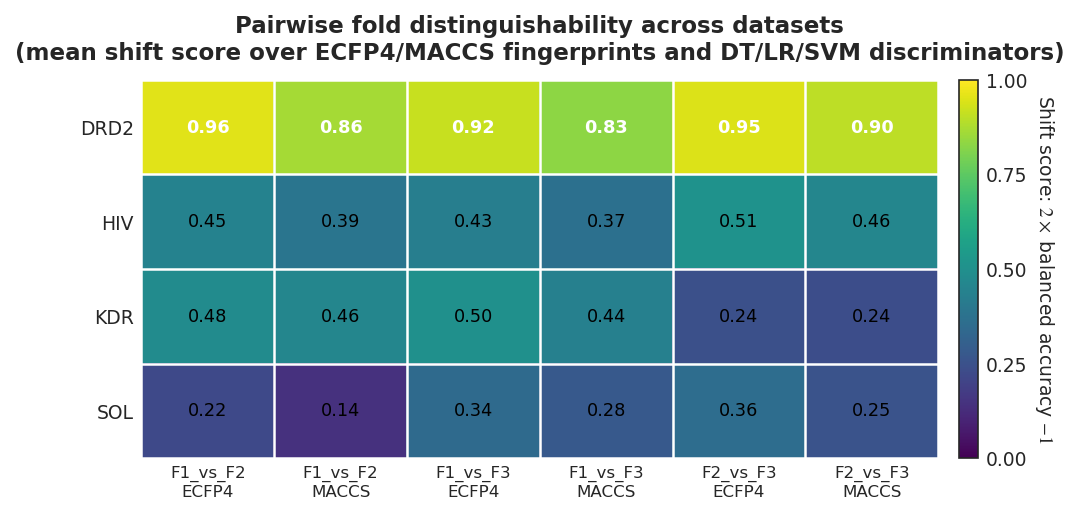

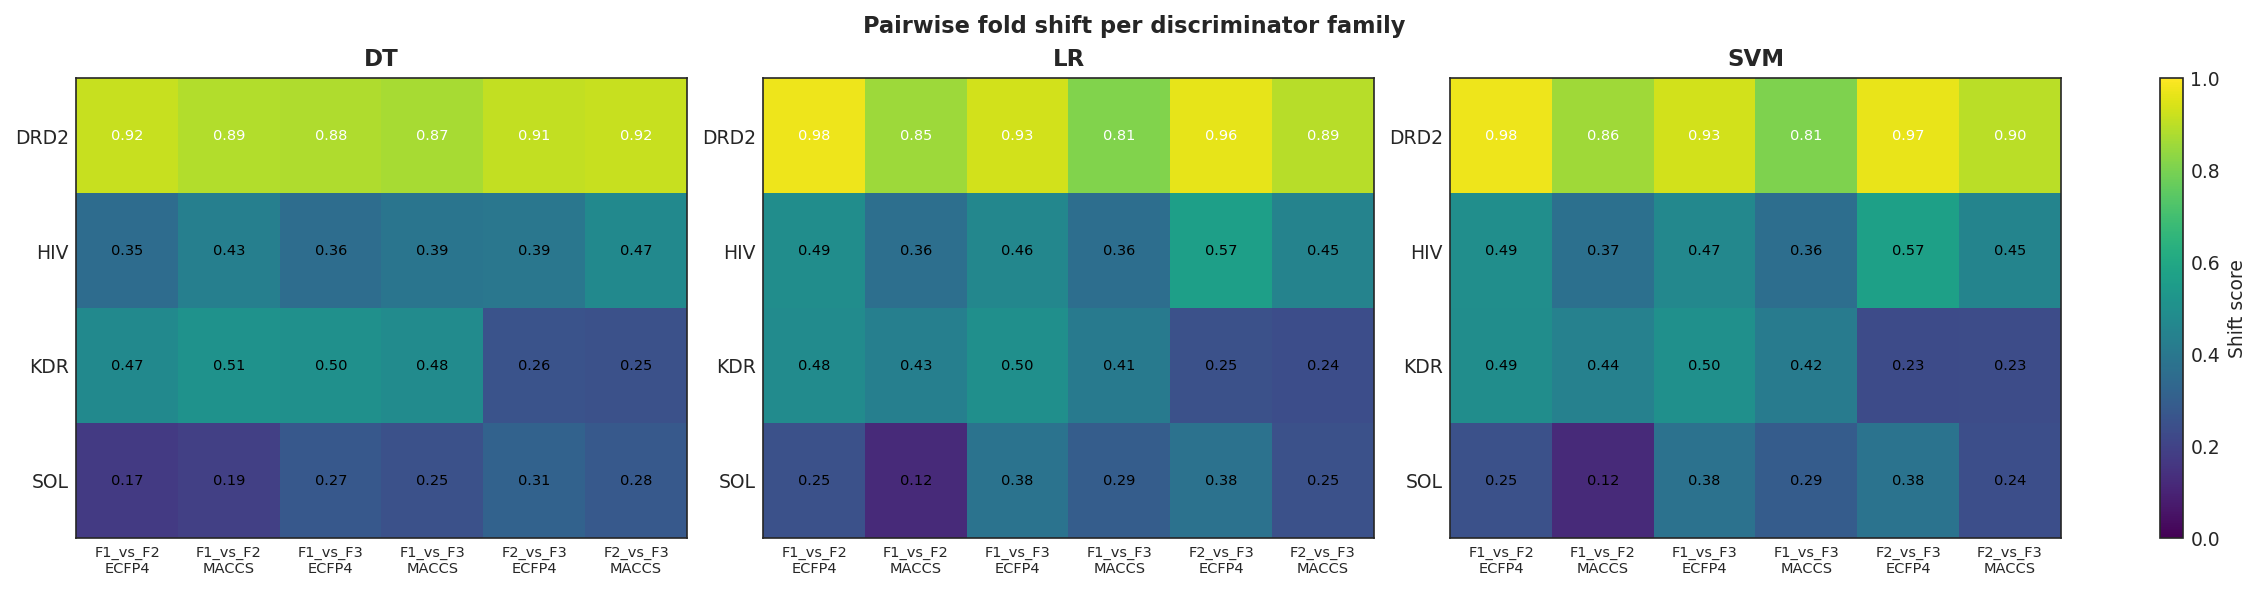

In [ ]:
from textwrap import wrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Global figure directory
FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

PLOT_FPS = ["ecfp4", "maccs"]

df_shift_plot = (
    df_search_cv
    .query("fingerprint in @PLOT_FPS")
    .groupby(["dataset", "pair", "fingerprint"], as_index=False)["shift_score_01"]
    .mean()
)

df_shift_plot["column"] = (
    df_shift_plot["pair"] + "\n" + df_shift_plot["fingerprint"].str.upper()
)

shift_mat = (
    df_shift_plot
    .pivot(index="dataset", columns="column", values="shift_score_01")
    .reindex(DATASETS)
)

ordered_cols = []
for pair in ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]:
    for fp in ["ECFP4", "MACCS"]:
        col = f"{pair}\n{fp}"
        if col in shift_mat.columns:
            ordered_cols.append(col)

shift_mat = shift_mat[ordered_cols]

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
})

n_rows, n_cols = shift_mat.shape

fig_width = max(6.8, 1.0 * n_cols)
fig_height = max(2.6, 0.55 * n_rows + 1.3)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Mask missing values, if any
data = np.ma.masked_invalid(shift_mat.values.astype(float))

cmap = mpl.colormaps["viridis"].copy()
cmap.set_bad(color="lightgray")

im = ax.imshow(
    data,
    vmin=0,
    vmax=1,
    cmap=cmap,
    aspect="auto",
    interpolation="nearest",
)

ax.set_title(
    "Pairwise fold distinguishability across datasets\n"
    "(mean shift score over ECFP4/MACCS fingerprints and DT/LR/SVM discriminators)",
    pad=10, fontweight="bold",
)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(shift_mat.columns, rotation=0, ha="center")

ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels([d.upper() for d in shift_mat.index])

ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(n_rows):
    for j in range(n_cols):
        value = shift_mat.iloc[i, j]

        if pd.notna(value):
            text_color = "white" if value >= 0.62 else "black"

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.5,
                color=text_color,
                fontweight="bold" if value >= 0.80 else "normal",
            )

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.025,
)

cbar.set_label(
    r"Shift score: $2 \times$ balanced accuracy $- 1$",
    rotation=270,
    labelpad=14,
)

cbar.set_ticks([0, 0.25, 0.50, 0.75, 1.00])
cbar.ax.tick_params(length=0)

fig.tight_layout()

fig.savefig(
    FIG_ROOT / "global_fold_shift_heatmap_shift_score_01.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / "global_fold_shift_heatmap_shift_score_01.pdf",
    bbox_inches="tight",
)

plt.show()

# Per-model shift heatmaps (one panel per discriminator family)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), constrained_layout=True)

for ax, model_name in zip(axes, ["DT", "LR", "SVM"]):
    sub = (
        df_search_cv
        .query("fingerprint in @PLOT_FPS and model == @model_name")
        .groupby(["dataset", "pair", "fingerprint"], as_index=False)["shift_score_01"]
        .mean()
    )
    sub["column"] = sub["pair"] + "\n" + sub["fingerprint"].str.upper()
    mat = sub.pivot(index="dataset", columns="column", values="shift_score_01").reindex(DATASETS)
    mat = mat[[c for c in ordered_cols if c in mat.columns]]

    im = ax.imshow(
        np.ma.masked_invalid(mat.values.astype(float)),
        vmin=0, vmax=1, cmap=cmap, aspect="auto", interpolation="nearest",
    )
    ax.set_title(model_name, fontweight="bold")
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=0, fontsize=7)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels([d.upper() for d in mat.index])
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iloc[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        fontsize=7, color="white" if v >= 0.62 else "black")

fig.colorbar(im, ax=axes, fraction=0.02, label="Shift score")
fig.suptitle("Pairwise fold shift per discriminator family", fontweight="bold", y=1.05)
fig.savefig(FIG_ROOT / "shift_heatmap_per_model.png", dpi=600, bbox_inches="tight")
plt.show()

## Fold-Aware List A vs List B Feature Overlap

Lo shift coinvolge le stesse feature del modello di attività?

In [ ]:


PLOT_FPS = ["ecfp4", "maccs"]
OVERLAP_K = 20
LISTB_SOURCE = "same_search_cv"

PAIR_TO_OUTER_FOLD = {
    "F1_vs_F2": 1,
    "F1_vs_F3": 2,
    "F2_vs_F3": 3,
}


def top_features_from_listB(
    df_b: pd.DataFrame,
    dataset: str,
    pair: str,
    model: str,
    fingerprint: str,
    source: str,
    k: int,
) -> set:
    """
    Top-k shift/discriminator features for one dataset-pair-model-fingerprint.
    """
    sub = df_b[
        (df_b["dataset"] == dataset)
        & (df_b["pair"] == pair)
        & (df_b["model"] == model)
        & (df_b["fingerprint"] == fingerprint)
        & (df_b["source"] == source)
    ].copy()

    if sub.empty:
        return set()

    sub = sub.sort_values("rank", ascending=True)

    return set(sub.head(k)["feature_idx"].astype(int))


def top_features_listA_by_protocol_and_fold(
    df_a: pd.DataFrame,
    dataset: str,
    model: str,
    fingerprint: str,
    protocol: str,
    fold: int,
    k: int,
) -> set:
    """
    Top-k activity features for one dataset-model-fingerprint-protocol-fold.

    This aligns List A with the same outer fold corresponding to the List B pair:
        F1_vs_F2 -> fold 1
        F1_vs_F3 -> fold 2
        F2_vs_F3 -> fold 3
    """
    sub = df_a[
        (df_a["dataset"] == dataset)
        & (df_a["model"] == model)
        & (df_a["fingerprint"] == fingerprint)
        & (df_a["protocol"].astype(str).str.lower().str.contains(protocol.lower()))
        & (df_a["fold"].astype(int) == int(fold))
    ].copy()

    if sub.empty:
        return set()

    agg = (
        sub.groupby("feature_idx", as_index=False)["activity_importance"]
        .mean()
        .sort_values("activity_importance", ascending=False)
    )

    return set(agg.head(k)["feature_idx"].astype(int))


overlap_rows = []

PROTOCOLS = ["OOD holdout", "Random shuffle"]

PROTOCOL_SHORT = {
    "OOD holdout": "ood",
    "Random shuffle": "random",
}

for dataset in DATASETS:
    for fold_a, fold_b in PAIRS:
        pair_name = f"{fold_a}_vs_{fold_b}"
        outer_fold = PAIR_TO_OUTER_FOLD[pair_name]

        for fp in PLOT_FPS:
            for model in ["DT", "LR", "SVM"]:

                b_features = top_features_from_listB(
                    df_b=df_listB,
                    dataset=dataset,
                    pair=pair_name,
                    model=model,
                    fingerprint=fp,
                    source=LISTB_SOURCE,
                    k=OVERLAP_K,
                )

                if not b_features:
                    continue

                for protocol in PROTOCOLS:
                    a_features = top_features_listA_by_protocol_and_fold(
                        df_a=df_listA,
                        dataset=dataset,
                        model=model,
                        fingerprint=fp,
                        protocol=protocol,
                        fold=outer_fold,
                        k=OVERLAP_K,
                    )

                    if not a_features:
                        continue

                    common_features = a_features & b_features
                    overlap = len(common_features) / OVERLAP_K

                    overlap_rows.append({
                        "dataset": dataset,
                        "pair": pair_name,
                        "outer_fold": outer_fold,
                        "fingerprint": fp,
                        "model": model,
                        "activity_protocol": PROTOCOL_SHORT[protocol],
                        "k": OVERLAP_K,
                        "overlap": overlap,
                        "n_overlap": len(common_features),
                        "overlap_features": json.dumps(sorted(list(common_features))),
                    })

df_overlap = pd.DataFrame(overlap_rows)

df_overlap.to_csv(
    OUT_ROOT / f"cross_dataset_listA_listB_overlap_by_protocol_foldaware_top{OVERLAP_K}.csv",
    index=False,
)

display(df_overlap.head(12))

,dataset,pair,outer_fold,fingerprint,model,activity_protocol,k,overlap,n_overlap,overlap_features
0,drd2,F1_vs_F2,1,ecfp4,DT,ood,20,0.10,2,"[74, 648]"
1,drd2,F1_vs_F2,1,ecfp4,DT,random,20,0.05,1,[441]
2,drd2,F1_vs_F2,1,ecfp4,LR,ood,20,0.05,1,[268]
3,drd2,F1_vs_F2,1,ecfp4,LR,random,20,0.00,0,[]
4,drd2,F1_vs_F2,1,maccs,DT,ood,20,0.25,5,"[79, 82, 90, 104, 115]"
5,drd2,F1_vs_F2,1,maccs,DT,random,20,0.15,3,"[103, 104, 133]"
6,drd2,F1_vs_F2,1,maccs,LR,ood,20,0.15,3,"[24, 85, 99]"
7,drd2,F1_vs_F2,1,maccs,LR,random,20,0.25,5,"[64, 78, 85, 99, 162]"
8,drd2,F1_vs_F3,2,ecfp4,DT,ood,20,0.10,2,"[521, 551]"
9,drd2,F1_vs_F3,2,ecfp4,DT,random,20,0.05,1,[121]


## 15. Feature-Overlap Heatmaps by Validation Protocol

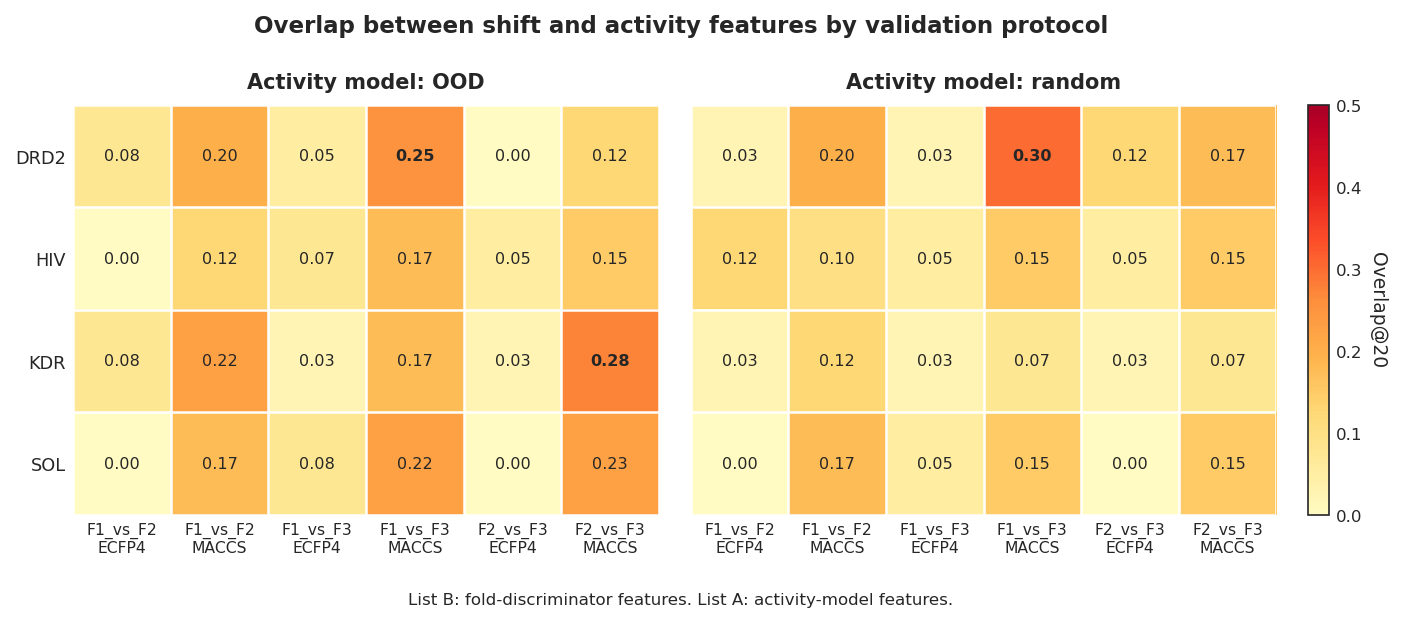

In [103]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8.5,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 8.5,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
})

base_cmap = mpl.colormaps["YlOrRd"]
colors = base_cmap(np.linspace(0.03, 0.92, 256))
cmap = mpl.colors.LinearSegmentedColormap.from_list("truncated_YlOrRd", colors)
cmap.set_bad(color="lightgray")

ordered_cols = []
for pair in ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]:
    for fp in ["ECFP4", "MACCS"]:
        ordered_cols.append(f"{pair}\n{fp}")

protocol_labels = {
    "ood": "Activity model: OOD",
    "random": "Activity model: random",
}

vmin = 0.0
vmax = 0.50

fig = plt.figure(figsize=(10.8, 3.55))

gs = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1, 1, 0.035],
    wspace=0.08,
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
]

cax = fig.add_subplot(gs[0, 2])

last_im = None

for ax, protocol in zip(axes, ["ood", "random"]):
    sub = (
        df_overlap
        .query("activity_protocol == @protocol")
        .groupby(["dataset", "pair", "fingerprint"], as_index=False)["overlap"]
        .mean()
    )

    sub["column"] = (
        sub["pair"] + "\n" + sub["fingerprint"].str.upper()
    )

    mat = (
        sub
        .pivot(index="dataset", columns="column", values="overlap")
        .reindex(DATASETS)
    )

    mat = mat[[c for c in ordered_cols if c in mat.columns]]

    data = np.ma.masked_invalid(mat.values.astype(float))

    last_im = ax.imshow(
        data,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_title(
        protocol_labels[protocol],
        fontweight="bold",
        pad=8,
    )

    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=0, ha="center")

    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels([d.upper() for d in mat.index])

    ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)

    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(axis="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iloc[i, j]

            if pd.notna(v):
                ax.text(
                    j,
                    i,
                    f"{v:.2f}",
                    ha="center",
                    va="center",
                    fontsize=7.7,
                    color="0.15",
                    fontweight="bold" if v >= 0.25 else "normal",
                )

axes[1].tick_params(labelleft=False)

cbar = fig.colorbar(
    last_im,
    cax=cax,
)

cbar.set_label(
    f"Overlap@{OVERLAP_K}",
    rotation=270,
    labelpad=12,
)

cbar.set_ticks(np.linspace(vmin, vmax, 6))
cbar.ax.tick_params(length=0, labelsize=8)

fig.suptitle(
    "Overlap between shift and activity features by validation protocol",
    fontweight="bold",
    y=1.05,
    fontsize=11,
)

fig.text(
    0.5,
    -0.035,
    "List B: fold-discriminator features. List A: activity-model features.",
    ha="center",
    va="top",
    fontsize=8,
)

fig.savefig(
    FIG_ROOT / f"listA_listB_overlap_by_protocol_top{OVERLAP_K}_paper_final.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / f"listA_listB_overlap_by_protocol_top{OVERLAP_K}_paper_final.pdf",
    bbox_inches="tight",
)

plt.show()

## Global Feature-Overlap Heatmap

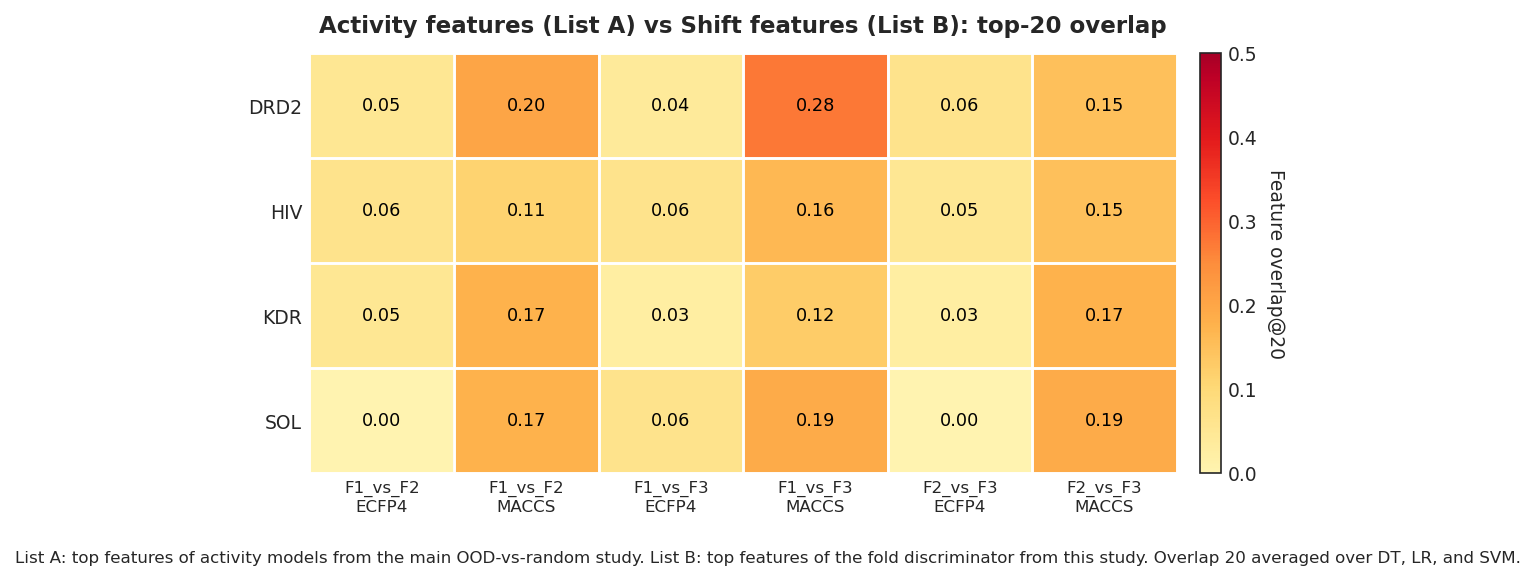

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

df_overlap_plot = (
    df_overlap
    .groupby(["dataset", "pair", "fingerprint"], as_index=False)["overlap"]
    .mean()
)

df_overlap_plot["column"] = (
    df_overlap_plot["pair"] + "\n" + df_overlap_plot["fingerprint"].str.upper()
)

overlap_mat = (
    df_overlap_plot
    .pivot(index="dataset", columns="column", values="overlap")
    .reindex(DATASETS)
)

ordered_cols = []
for pair in ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]:
    for fp in ["ECFP4", "MACCS"]:
        col = f"{pair}\n{fp}"
        if col in overlap_mat.columns:
            ordered_cols.append(col)

overlap_mat = overlap_mat[ordered_cols]

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
})

n_rows, n_cols = overlap_mat.shape

fig, ax = plt.subplots(figsize=(7.2, 3.6))

data = np.ma.masked_invalid(overlap_mat.values.astype(float))

base_cmap = mpl.colormaps["YlOrRd"]
colors = base_cmap(np.linspace(0.08, 0.92, 256))
cmap = mpl.colors.LinearSegmentedColormap.from_list("truncated_YlOrRd", colors)
cmap.set_bad(color="lightgray")

vmax = 0.50

im = ax.imshow(
    data,
    vmin=0,
    vmax=vmax,
    cmap=cmap,
    aspect="auto",
    interpolation="nearest",
)

ax.set_title(
    "Activity features (List A) vs Shift features (List B): top-20 overlap",
    pad=10, fontweight="bold",
)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(overlap_mat.columns, rotation=0, ha="center")

ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels([d.upper() for d in overlap_mat.index])

ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

ax.grid(which="minor", color="white", linewidth=1.4)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(n_rows):
    for j in range(n_cols):
        value = overlap_mat.iloc[i, j]

        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.5,
                color="black",
                fontweight="bold" if value >= 0.30 else "normal",
            )

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.025,
)

cbar.set_label(
    f"Feature overlap@{OVERLAP_K}",
    rotation=270,
    labelpad=13,
)

cbar.set_ticks(np.linspace(0, vmax, 6))
cbar.ax.tick_params(length=0)

fig.text(
    0.5, -0.03,
    "List A: top features of activity models from the main OOD-vs-random study. "
    "List B: top features of the fold discriminator from this study. "
    f"Overlap {OVERLAP_K} averaged over DT, LR, and SVM.",
    ha="center", va="top", fontsize=8,
)

fig.tight_layout()

fig.savefig(
    FIG_ROOT / f"global_listA_listB_overlap_heatmap_top{OVERLAP_K}_paper_light.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / f"global_listA_listB_overlap_heatmap_top{OVERLAP_K}_paper_light.pdf",
    bbox_inches="tight",
)

plt.show()

## Load OOD-vs-Random Per-Fold Protocol Results



In [93]:
OOD_ROOT = PROJECT_ROOT / "results" / "results_ood_vs_random_shuffle" / TASK

OUTER_FOLD_TO_PAIR = {
    1: "F1_vs_F2",
    2: "F1_vs_F3",
    3: "F2_vs_F3",
}


def load_protocol_per_fold_for_dataset(dataset: str) -> pd.DataFrame:
    path = OOD_ROOT / dataset / "protocol_per_fold.csv"

    if not path.exists():
        raise FileNotFoundError(f"Missing protocol_per_fold.csv for {dataset}: {path}")

    df = pd.read_csv(path).copy()
    df["dataset"] = dataset
    return df


protocol_parts = []

for dataset in DATASETS:
    try:
        protocol_parts.append(load_protocol_per_fold_for_dataset(dataset))
    except FileNotFoundError as e:
        print(e)

df_protocol_per_fold = pd.concat(protocol_parts, ignore_index=True)

print("protocol_per_fold columns:")
print(df_protocol_per_fold.columns.tolist())

display(df_protocol_per_fold.head())

protocol_per_fold columns:
['model', 'model_short', 'fingerprint', 'protocol', 'result_dir', 'fold', 'inner_pr_auc', 'inner_train_pr_auc', 'train_pr_auc', 'test_pr_auc', 'inner_test_gap', 'train_test_gap', 'best_params', 'inner_split_strategy', 'time_seconds', 'model_order', 'fingerprint_order', 'protocol_order', 'dataset']


,model,model_short,fingerprint,protocol,result_dir,fold,inner_pr_auc,inner_train_pr_auc,train_pr_auc,test_pr_auc,inner_test_gap,train_test_gap,best_params,inner_split_strategy,time_seconds,model_order,fingerprint_order,protocol_order,dataset
0,Decision Tree,DT,ECFP4,OOD holdout,dt_drd2_hi_inner_ood_holdout_ecfp4,1,0.855177,0.917171,0.9080,0.6979,0.157277,0.2101,"{'ccp_alpha': 0.001, 'class_weight': None, 'cr...",holdout,9.5,0,0,0,drd2
1,Decision Tree,DT,ECFP4,OOD holdout,dt_drd2_hi_inner_ood_holdout_ecfp4,2,0.699841,0.873181,0.8189,0.7698,-0.069959,0.0491,"{'ccp_alpha': 0.001, 'class_weight': None, 'cr...",holdout,6.2,0,0,0,drd2
2,Decision Tree,DT,ECFP4,OOD holdout,dt_drd2_hi_inner_ood_holdout_ecfp4,3,0.737516,0.905641,0.8232,0.6815,0.056016,0.1417,"{'ccp_alpha': 0.0001, 'class_weight': None, 'c...",holdout,6.3,0,0,0,drd2
3,Decision Tree,DT,ECFP4,Random shuffle,dt_drd2_hi_random_shuffle_ecfp4,1,0.911535,0.960189,0.9522,0.6237,0.287835,0.3285,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',...",random_shuffle,13.3,0,0,1,drd2
4,Decision Tree,DT,ECFP4,Random shuffle,dt_drd2_hi_random_shuffle_ecfp4,2,0.844398,0.904329,0.8757,0.7540,0.090398,0.1217,"{'ccp_alpha': 0.0001, 'class_weight': None, 'c...",random_shuffle,10.6,0,0,1,drd2


## Pairwise Shift vs OOD-vs-Random Protocol Gap

In [94]:
def infer_fold_column(df: pd.DataFrame) -> str:
    candidates = ["fold", "outer_fold", "fold_id", "test_fold"]

    for col in candidates:
        if col in df.columns:
            return col

    raise ValueError(
        "Could not infer fold column. "
        f"Available columns: {df.columns.tolist()}"
    )

In [ ]:
# Pairwise shift vs OOD-vs-random validation gap
#
# Two complementary gaps, both built from protocol_per_fold.csv:
#
# 1. optimism_gap_diff:
#       optimism_gap_random  =  inner_pr_auc_random  - test_pr_auc_random
#       optimism_gap_ood     =  inner_pr_auc_ood     - test_pr_auc_ood
#       optimism_gap_diff    =  optimism_gap_random  - optimism_gap_ood
#    Positive value: random validation is more optimistic than OOD validation.
#
# 2. test_gap:
#       test_gap = test_pr_auc_ood - test_pr_auc_random
#    Positive value: OOD-selected model beats random-selected model on the real OOD test set.
# ============================================================

PLOT_FPS = ["ecfp4", "maccs"]

OUTER_FOLD_TO_PAIR = {
    1: "F1_vs_F2",
    2: "F1_vs_F3",
    3: "F2_vs_F3",
}

# Shift table (averaged over fingerprints and models for the overview)
df_shift_pair = (
    df_search_cv
    .query("fingerprint in @PLOT_FPS")
    .groupby(["dataset", "pair"], as_index=False)["shift_score_01"]
    .mean()
)

# Build the per-fold protocol table
df_gap_raw = df_protocol_per_fold.copy()
df_gap_raw["fingerprint_norm"] = df_gap_raw["fingerprint"].astype(str).str.lower()
df_gap_raw["model_short_norm"] = df_gap_raw["model_short"].astype(str).str.upper()

df_gap_raw = df_gap_raw[
    df_gap_raw["fingerprint_norm"].isin(PLOT_FPS)
    & df_gap_raw["model_short_norm"].isin(["DT", "LR", "SVM"])
].copy()
df_gap_raw["protocol_norm"] = df_gap_raw["protocol"].astype(str).str.lower()

def protocol_family(x: str) -> str:
    if "random" in x:
        return "random"
    if "ood" in x or "holdout" in x:
        return "ood"
    return x

df_gap_raw["protocol_family"] = df_gap_raw["protocol_norm"].map(protocol_family)
df_gap_raw = df_gap_raw[df_gap_raw["protocol_family"].isin(["random", "ood"])].copy()

df_gap_raw["outer_fold"] = df_gap_raw["fold"].astype(int)
df_gap_raw["pair"] = df_gap_raw["outer_fold"].map(OUTER_FOLD_TO_PAIR)

# Per-fold optimism gap, per protocol
df_gap_raw["optimism_gap"] = df_gap_raw["inner_pr_auc"] - df_gap_raw["test_pr_auc"]

df_gap_agg = (
    df_gap_raw
    .groupby(["dataset", "pair", "protocol_family"], as_index=False)
    .agg(
        inner_pr_auc=("inner_pr_auc", "mean"),
        test_pr_auc=("test_pr_auc", "mean"),
        optimism_gap=("optimism_gap", "mean"),
    )
)

# Pivot random vs OOD
df_gap_pivot = df_gap_agg.pivot_table(
    index=["dataset", "pair"],
    columns="protocol_family",
    values=["inner_pr_auc", "test_pr_auc", "optimism_gap"],
).reset_index()

df_gap_pivot.columns = [
    "_".join(c).rstrip("_") if isinstance(c, tuple) else c
    for c in df_gap_pivot.columns
]

df_gap_pivot["optimism_gap_diff"] = (
    df_gap_pivot["optimism_gap_random"] - df_gap_pivot["optimism_gap_ood"]
)
df_gap_pivot["test_gap"] = (
    df_gap_pivot["test_pr_auc_ood"] - df_gap_pivot["test_pr_auc_random"]
)

df_gap_pair = df_gap_pivot[[
    "dataset", "pair",
    "inner_pr_auc_random", "inner_pr_auc_ood",
    "test_pr_auc_random",  "test_pr_auc_ood",
    "optimism_gap_random", "optimism_gap_ood",
    "optimism_gap_diff",
    "test_gap",
]].copy()

df_shift_gap = df_shift_pair.merge(df_gap_pair, on=["dataset", "pair"], how="inner")

df_shift_gap.to_csv(
    OUT_ROOT / "cross_dataset_pairwise_shift_vs_protocol_gap.csv",
    index=False,
)

display(df_shift_gap.round(3))

,dataset,pair,shift_score_01,inner_pr_auc_random,inner_pr_auc_ood,test_pr_auc_random,test_pr_auc_ood,optimism_gap_random,optimism_gap_ood,optimism_gap_diff,test_gap
0,drd2,F1_vs_F2,0.911,0.910,0.838,0.640,0.656,0.270,0.182,0.089,0.016
1,drd2,F1_vs_F3,0.872,0.857,0.698,0.806,0.808,0.051,-0.110,0.161,0.002
2,drd2,F2_vs_F3,0.924,0.903,0.717,0.746,0.732,0.156,-0.015,0.171,-0.014
3,hiv,F1_vs_F2,0.417,0.342,0.106,0.116,0.110,0.226,-0.004,0.229,-0.006
4,hiv,F1_vs_F3,0.399,0.376,0.150,0.082,0.082,0.293,0.067,0.226,-0.000
5,hiv,F2_vs_F3,0.484,0.427,0.164,0.033,0.034,0.394,0.130,0.264,0.000
6,kdr,F1_vs_F2,0.471,0.981,0.865,0.564,0.902,0.418,-0.037,0.455,0.338
7,kdr,F1_vs_F3,0.468,0.383,0.782,0.737,0.930,-0.354,-0.147,-0.207,0.192
8,kdr,F2_vs_F3,0.241,0.972,0.857,0.604,0.901,0.368,-0.044,0.412,0.297
9,sol,F1_vs_F2,0.183,0.519,0.452,0.411,0.438,0.108,0.014,0.094,0.027


## Scatter Plot: Shift Score vs OOD Test Benefit

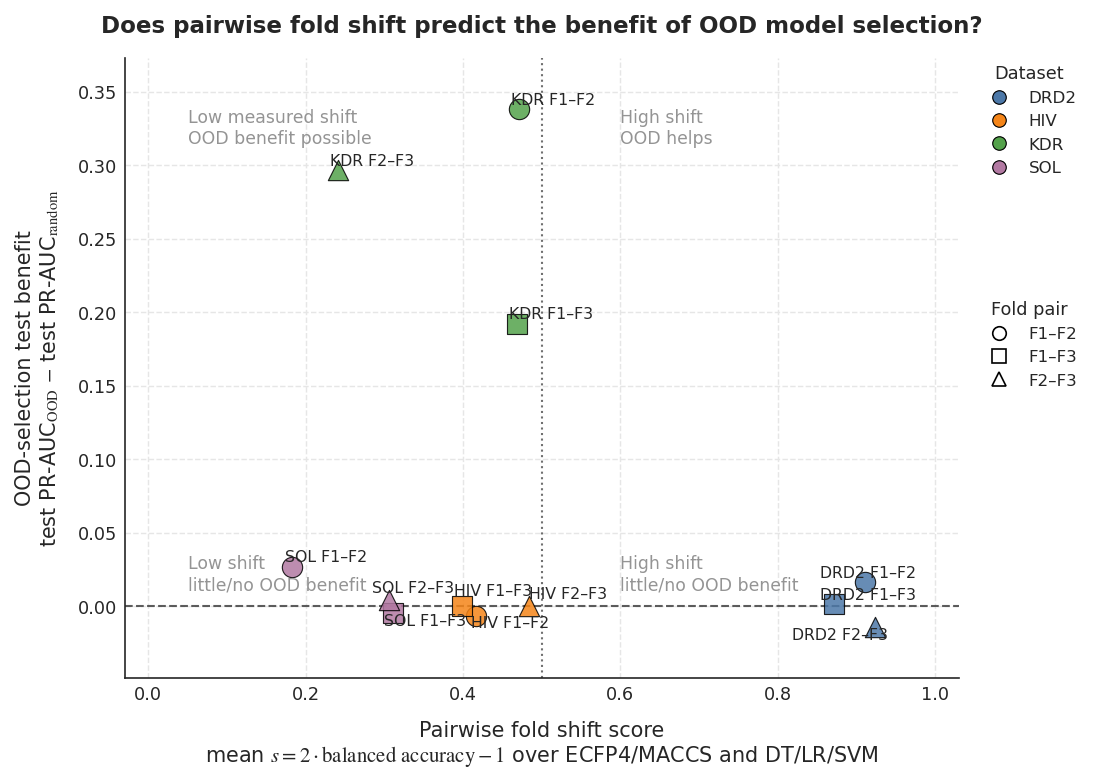

In [ ]:
# Plot: pairwise fold shift vs OOD-selection test benefit

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from adjustText import adjust_text

FIG_ROOT = OUT_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8,
    "legend.title_fontsize": 8.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
})

# Positive value = OOD-based model selection improves final OOD test PR-AUC.
GAP_COL = "test_gap"

GAP_LABEL = (
    "OOD-selection test benefit\n"
    r"test PR-AUC$_{\mathrm{OOD}}$ $-$ test PR-AUC$_{\mathrm{random}}$"
)

SHIFT_THRESHOLD = 0.50

markers = {
    "F1_vs_F2": "o",
    "F1_vs_F3": "s",
    "F2_vs_F3": "^",
}

dataset_colors = {
    "DRD2": "#4C78A8",
    "HIV":  "#F58518",
    "KDR":  "#54A24B",
    "SOL":  "#B279A2",
}

fig, ax = plt.subplots(figsize=(7.4, 5.3))

texts = []

for _, row in df_shift_gap.iterrows():
    dataset = row["dataset"].upper()
    pair = row["pair"]

    x = row["shift_score_01"]
    y = row[GAP_COL]

    ax.scatter(
        x,
        y,
        s=95,
        marker=markers.get(pair, "o"),
        facecolor=dataset_colors.get(dataset, "gray"),
        edgecolor="black",
        linewidth=0.55,
        alpha=0.85,
        zorder=3,
    )

    texts.append(
        ax.text(
            x,
            y,
            f"{dataset} {pair.replace('_vs_', '–')}",
            fontsize=7.6,
            color="0.15",
            zorder=4,
        )
    )

adjust_text(
    texts,
    ax=ax,
    expand=(1.15, 1.25),
    force_text=(0.25, 0.35),
    force_static=(0.15, 0.25),
    only_move={"text": "xy"},
)

ax.axhline(
    0.0,
    color="0.25",
    linestyle="--",
    linewidth=1.0,
    alpha=0.85,
    zorder=1,
)

ax.axvline(
    SHIFT_THRESHOLD,
    color="0.25",
    linestyle=":",
    linewidth=1.0,
    alpha=0.75,
    zorder=1,
)

ax.set_xlim(-0.03, 1.03)

y_min = min(-0.04, df_shift_gap[GAP_COL].min() - 0.035)
y_max = max(0.36, df_shift_gap[GAP_COL].max() + 0.035)
ax.set_ylim(y_min, y_max)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    color="0.90",
    zorder=0,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

quad_style = dict(
    fontsize=8.3,
    color="0.58",
    ha="left",
    va="top",
)

ax.text(
    0.05,
    y_max - 0.035,
    "Low measured shift\nOOD benefit possible",
    **quad_style,
)

ax.text(
    0.60,
    y_max - 0.035,
    "High shift\nOOD helps",
    **quad_style,
)

ax.text(
    0.60,
    0.035,
    "High shift\nlittle/no OOD benefit",
    fontsize=8.3,
    color="0.58",
    ha="left",
    va="top",
)

ax.text(
    0.05,
    0.035,
    "Low shift\nlittle/no OOD benefit",
    fontsize=8.3,
    color="0.58",
    ha="left",
    va="top",
)

ax.set_xlabel(
    "Pairwise fold shift score\n"
    r"mean $s = 2 \cdot \mathrm{balanced\ accuracy} - 1$ over ECFP4/MACCS and DT/LR/SVM",
    labelpad=8,
)

ax.set_ylabel(GAP_LABEL, labelpad=8)

ax.set_title(
    "Does pairwise fold shift predict the benefit of OOD model selection?",
    pad=12,
    fontweight="bold",
)

dataset_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=color,
        markeredgecolor="black",
        markeredgewidth=0.55,
        markersize=6.5,
        label=dataset,
    )
    for dataset, color in dataset_colors.items()
]

pair_handles = [
    Line2D(
        [0],
        [0],
        marker=marker,
        linestyle="",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=0.8,
        markersize=6.5,
        label=pair.replace("_vs_", "–"),
    )
    for pair, marker in markers.items()
]

legend_1 = ax.legend(
    handles=dataset_handles,
    title="Dataset",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False,
    borderaxespad=0.0,
)

ax.add_artist(legend_1)

ax.legend(
    handles=pair_handles,
    title="Fold pair",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.62),
    frameon=False,
    borderaxespad=0.0,
)

fig.tight_layout()

fig.savefig(
    FIG_ROOT / "pairwise_shift_vs_test_gap_quadrants_paper.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    FIG_ROOT / "pairwise_shift_vs_test_gap_quadrants_paper.pdf",
    bbox_inches="tight",
)

plt.show()

## KDR Diagnostic: High-Capacity Tree Separability

In [111]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, accuracy_score
import numpy as np
import pandas as pd

def shift_scores_from_balanced_accuracy(bal_acc: float) -> tuple[float, float]:
    shift_score_01 = max(0.0, 2.0 * bal_acc - 1.0)
    proxy_a_distance = max(0.0, 4.0 * bal_acc - 2.0)
    return shift_score_01, proxy_a_distance


def make_high_capacity_dt() -> DecisionTreeClassifier:
    return DecisionTreeClassifier(
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        ccp_alpha=0.0,
        random_state=RANDOM_STATE,
    )

def make_high_capacity_dt() -> DecisionTreeClassifier:
    """
    High-capacity Decision Tree used for in-sample diagnostic separability.
    Same configuration used in the high-capacity in-sample block.
    """
    return DecisionTreeClassifier(
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        ccp_alpha=0.0,
        random_state=RANDOM_STATE,
    )


kdr_dt_diagnostic_rows = []

subsets_kdr = load_subsets("kdr")

for fp_type in FINGERPRINTS:
    for fold_a, fold_b in PAIRS:
        pair_name = f"{fold_a}_vs_{fold_b}"

        try:
            with silence_output():
                X, y, feature_names, pair_df = build_pair_dataset(
                    dataset="kdr",
                    subsets=subsets_kdr,
                    fold_a=fold_a,
                    fold_b=fold_b,
                    fp_type=fp_type,
                )
        except Exception as e:
            print(f"Skip kdr | {pair_name} | {fp_type}: {e}")
            continue

        dt = make_high_capacity_dt()

        with silence_output():
            dt.fit(X, y)

        y_pred = dt.predict(X)

        tree = dt.tree_
        leaf_mask = tree.children_left == -1
        leaf_samples = tree.n_node_samples[leaf_mask]

        cm = confusion_matrix(y, y_pred, labels=[0, 1])

        acc = accuracy_score(y, y_pred)
        bal_acc = balanced_accuracy_score(y, y_pred)
        shift_score_01, proxy_a_distance = shift_scores_from_balanced_accuracy(bal_acc)

        row = {
            "dataset": "kdr",
            "pair": pair_name,
            "fold_a": fold_a,
            "fold_b": fold_b,
            "fingerprint": fp_type,
            "model": "DT",
            "accuracy": acc,
            "balanced_accuracy": bal_acc,
            "shift_score_01": shift_score_01,
            "proxy_A_distance": proxy_a_distance,
            "n_samples": len(y),
            "n_class_0": int((y == 0).sum()),
            "n_class_1": int((y == 1).sum()),
            "n_nodes": int(tree.node_count),
            "n_leaves": int(leaf_mask.sum()),
            "leaf_min_samples": int(leaf_samples.min()),
            "leaf_median_samples": float(np.median(leaf_samples)),
            "leaf_mean_samples": float(np.mean(leaf_samples)),
            "n_singleton_leaves": int((leaf_samples == 1).sum()),
            "cm_00": int(cm[0, 0]),
            "cm_01": int(cm[0, 1]),
            "cm_10": int(cm[1, 0]),
            "cm_11": int(cm[1, 1]),
        }

        kdr_dt_diagnostic_rows.append(row)

        print(f"kdr | {pair_name} | {fp_type}")
        print(
            f"  n_nodes={row['n_nodes']}, "
            f"n_leaves={row['n_leaves']}, "
            f"singleton_leaves={row['n_singleton_leaves']}, "
            f"min_leaf={row['leaf_min_samples']}, "
            f"median_leaf={row['leaf_median_samples']:.1f}, "
            f"balanced_acc={bal_acc:.3f}, "
            f"shift_score={shift_score_01:.3f}"
        )
        print(f"  confusion matrix [rows=true, cols=pred]:\n{cm}\n")

df_kdr_dt_diagnostic = pd.DataFrame(kdr_dt_diagnostic_rows)

df_kdr_dt_diagnostic.to_csv(
    get_dataset_paths("kdr")["out_dir"] / "kdr_high_capacity_dt_diagnostic.csv",
    index=False,
)

display(df_kdr_dt_diagnostic.round(3))

kdr | F1_vs_F2 | ecfp4
  n_nodes=2647, n_leaves=1324, singleton_leaves=87, min_leaf=1, median_leaf=2.0, balanced_acc=0.816, shift_score=0.633
  confusion matrix [rows=true, cols=pred]:
[[2285    0]
 [1147 1978]]

kdr | F1_vs_F3 | ecfp4
  n_nodes=2529, n_leaves=1265, singleton_leaves=68, min_leaf=1, median_leaf=2.0, balanced_acc=0.817, shift_score=0.635
  confusion matrix [rows=true, cols=pred]:
[[2285    0]
 [1138 1978]]

kdr | F2_vs_F3 | ecfp4
  n_nodes=4311, n_leaves=2156, singleton_leaves=77, min_leaf=1, median_leaf=2.0, balanced_acc=0.683, shift_score=0.365
  confusion matrix [rows=true, cols=pred]:
[[3125    0]
 [1978 1138]]

kdr | F1_vs_F2 | maccs
  n_nodes=2461, n_leaves=1231, singleton_leaves=82, min_leaf=1, median_leaf=2.0, balanced_acc=0.816, shift_score=0.633
  confusion matrix [rows=true, cols=pred]:
[[2285    0]
 [1147 1978]]

kdr | F1_vs_F3 | maccs
  n_nodes=2459, n_leaves=1230, singleton_leaves=92, min_leaf=1, median_leaf=2.0, balanced_acc=0.817, shift_score=0.635
  conf

,dataset,pair,fold_a,fold_b,fingerprint,model,accuracy,balanced_accuracy,shift_score_01,proxy_A_distance,...,n_nodes,n_leaves,leaf_min_samples,leaf_median_samples,leaf_mean_samples,n_singleton_leaves,cm_00,cm_01,cm_10,cm_11
0,kdr,F1_vs_F2,F1,F2,ecfp4,DT,0.788,0.816,0.633,1.266,...,2647,1324,1,2.0,4.086,87,2285,0,1147,1978
1,kdr,F1_vs_F3,F1,F3,ecfp4,DT,0.789,0.817,0.635,1.270,...,2529,1265,1,2.0,4.270,68,2285,0,1138,1978
2,kdr,F2_vs_F3,F2,F3,ecfp4,DT,0.683,0.683,0.365,0.730,...,4311,2156,1,2.0,2.895,77,3125,0,1978,1138
3,kdr,F1_vs_F2,F1,F2,maccs,DT,0.788,0.816,0.633,1.266,...,2461,1231,1,2.0,4.395,82,2285,0,1147,1978
4,kdr,F1_vs_F3,F1,F3,maccs,DT,0.789,0.817,0.635,1.270,...,2459,1230,1,2.0,4.391,92,2285,0,1138,1978
5,kdr,F2_vs_F3,F2,F3,maccs,DT,0.683,0.683,0.365,0.730,...,3813,1907,1,2.0,3.273,116,3125,0,1978,1138
6,kdr,F1_vs_F2,F1,F2,rdkit_desc,DT,0.788,0.816,0.633,1.266,...,2657,1329,1,2.0,4.071,58,2285,0,1147,1978
7,kdr,F1_vs_F3,F1,F3,rdkit_desc,DT,0.789,0.817,0.635,1.270,...,2603,1302,1,2.0,4.148,64,2285,0,1138,1978
8,kdr,F2_vs_F3,F2,F3,rdkit_desc,DT,0.683,0.683,0.365,0.730,...,4373,2187,1,2.0,2.854,85,3125,0,1978,1138


In [109]:
subsets_kdr = load_subsets("kdr")

for a, b in PAIRS:
    smiles_a = set(subsets_kdr[a][get_smiles_col(subsets_kdr[a])])
    smiles_b = set(subsets_kdr[b][get_smiles_col(subsets_kdr[b])])
    inter = smiles_a & smiles_b

    print(f"{a}_vs_{b}")
    print(f"  |{a}| = {len(smiles_a)}")
    print(f"  |{b}| = {len(smiles_b)}")
    print(f"  overlap = {len(inter)}")
    print(f"  overlap / {a} = {len(inter) / len(smiles_a):.3f}")
    print(f"  overlap / {b} = {len(inter) / len(smiles_b):.3f}")
    print()

F1_vs_F2
  |F1| = 2285
  |F2| = 3125
  overlap = 1147
  overlap / F1 = 0.502
  overlap / F2 = 0.367

F1_vs_F3
  |F1| = 2285
  |F3| = 3116
  overlap = 1138
  overlap / F1 = 0.498
  overlap / F3 = 0.365

F2_vs_F3
  |F2| = 3125
  |F3| = 3116
  overlap = 1978
  overlap / F2 = 0.633
  overlap / F3 = 0.635

